# ROC comparison: SCMK vs 7 recent detectors (semi 50/50, seed=2)

One panel per dataset overlays the 8 methods' ROC curves. 20 datasets from
`selection_scatter_semi_seed2.csv`.

**Protocol (per method):**
- `SCMK`: seed-2 semi split, live CMK training, scored on the held-out test set.
- `KFGOD`, `DFNO`: transductive, scored on the FULL dataset (opt_out_scores) — DFNO
  uses `Experimental_results/DFNO_results`.
- `Disent-AD`/`DeepSVDD`/`LMKAD`: seed-2 split, cached per-sample test scores (res_single).
- `ICL`/`NeuTraLAD`: seed-2 split, cached per-sample test scores (CSV).

In [1]:
import os, sys
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')
import numpy as np
import pandas as pd
import scipy.io as sio
import torch
from sklearn.metrics import roc_curve, roc_auc_score

NB_DIR = 'C:/OD/Shihao/5/Granular-CMK/hybrid_score'
if NB_DIR not in sys.path:
    sys.path.insert(0, NB_DIR)
# self-contained semi module (does NOT import matplotlib -> avoids the Windows
# OpenMP crash that importing the old run_hybrid_score triggers alongside torch)
from run_hybrid_score_semi import (split_indices, extract_components, _best_ocsvm_scores,
                                   _minmax, gauss_med_kernels, load_data, _BASE_CFG,
                                   NU_CANDIDATES)
from CMK_OCSVM_scatter import train_cmk_scatter
import matplotlib.pyplot as plt

DATA_ROOT  = 'C:/OD/Shihao/datasets'
ER         = 'C:/OD/Shihao/Experimental_results'
KFGOD_DIR  = 'C:/OD/Shihao/KFGOD-main/results'
DFNO_DIR   = ER + '/DFNO_results'                 # full-data transductive DFNO
ICL_DIR    = 'C:/OD/Shihao/5/ICL and NeuTraLAD/results_split/scores/seed2'
SEMI_DIR   = 'C:/OD/Shihao/5/result/hybrid_score_semi'
RESULT_DIR = SEMI_DIR
SEL_CSV    = os.path.join(SEMI_DIR, 'selection_scatter_semi_seed2.csv')
ALL_CSV    = os.path.join(SEMI_DIR, 'hybrid_semi_all.csv')
SPLIT_SEED = 2
plt.rcParams['font.size'] = 13
plt.rcParams['font.family'] = 'Times New Roman'
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('device:', device, '| split_seed:', SPLIT_SEED)

device: cuda:0 | split_seed: 2


In [2]:
# Current 8-method set (plot order). DFNO is transductive on the FULL dataset, like KFGOD.
METHODS = ['KFGOD', 'Disent_AD', 'DeepSVDD', 'DFNO', 'LMKAD', 'ICL', 'NeuTraLAD', 'scatter']
LABEL = {'KFGOD': 'KFGOD', 'Disent_AD': 'Disent-AD', 'DeepSVDD': 'DeepSVDD', 'DFNO': 'DFNO',
         'LMKAD': 'LMKAD', 'ICL': 'ICL', 'NeuTraLAD': 'NeuTraLAD', 'scatter': 'SCMK'}
STYLE = {'KFGOD': ('#FF8C00', 'x', 1.1), 'Disent_AD': ('#BA55D3', '^', 1.1),
         'DeepSVDD': ('#20B2AA', '<', 1.1), 'DFNO': ('#00BFFF', 'v', 1.1),
         'LMKAD': ('#6B8E23', '>', 1.1), 'ICL': ('#8B4513', 's', 1.1),
         'NeuTraLAD': ('#FF69B4', 'p', 1.1), 'scatter': ('#DC143C', 'o', 1.5)}

sel = pd.read_csv(SEL_CSV); DATASETS = list(sel['dataset'])
_all = pd.read_csv(ALL_CSV); _s2 = _all[_all['split_seed'] == SPLIT_SEED]
BEST_CFG = {}
for st in DATASETS:
    sub = _s2[_s2['dataset'] == st]; br = sub.loc[sub['auc'].idxmax()]
    BEST_CFG[st] = (int(br['latent_dim']), float(br['lambda_scatter']))
print(f'{len(DATASETS)} datasets | 7 comparison algs + SCMK | DFNO=full-data transductive')

20 datasets | 7 comparison algs + SCMK | DFNO=full-data transductive


In [3]:
def load_full_y(stem):
    t = sio.loadmat(os.path.join(DATA_ROOT, stem + '.mat'))['trandata'].astype(float)
    return (t[:, -1] != 0).astype(int)

def full_data_scores(path, y):
    if not os.path.exists(path):
        return None
    s = np.asarray(sio.loadmat(path)['opt_out_scores'])[:, 0].ravel()
    return s if len(s) == len(y) else None

def seed2_mat_curve(path):
    r = sio.loadmat(path)['res_single'][0, 0]
    return (np.asarray(r['labels'], float).ravel().astype(int),
            np.asarray(r['opt_scores'], float).ravel())

def seed2_csv_curve(path):
    d = pd.read_csv(path)
    return d['label'].values.astype(int), d['anomaly_score'].values.astype(float)

def scatter_test_scores(stem, train_idx, test_idx):
    X, y, _ = load_data(os.path.join(DATA_ROOT, stem + '.mat'))
    dim, lam = BEST_CFG[stem]
    kernels = gauss_med_kernels(X[train_idx])
    cfg = {**_BASE_CFG, 'lambda_scatter': lam}
    model = train_cmk_scatter(X[train_idx], np.zeros(len(train_idx), int), kernels, dim, device, cfg)
    H_norm_per, H_norms = extract_components(model, X, device)
    H_dir = np.concatenate(H_norm_per, axis=1)
    y_test = (y[test_idx] != 0).astype(int)
    _, _, s_dir = _best_ocsvm_scores(H_dir[test_idx], y_test, H_dir[train_idx], 'linear', NU_CANDIDATES)
    _, _, s_nrm = _best_ocsvm_scores(H_norms[test_idx], y_test, H_norms[train_idx], 'rbf', NU_CANDIDATES)
    if s_dir is None: return y_test, _minmax(s_nrm)
    if s_nrm is None: return y_test, _minmax(s_dir)
    return y_test, np.maximum(_minmax(s_dir), _minmax(s_nrm))

def method_curve(m, stem, y_full, train_idx, test_idx):
    if m == 'scatter':
        return scatter_test_scores(stem, train_idx, test_idx)
    if m == 'KFGOD':
        s = full_data_scores(os.path.join(KFGOD_DIR, stem, f'{stem}_KFGOD.mat'), y_full)
        return (y_full, s) if s is not None else None
    if m == 'DFNO':
        s = full_data_scores(os.path.join(DFNO_DIR, stem, f'{stem}_DFNO.mat'), y_full)
        return (y_full, s) if s is not None else None
    if m == 'Disent_AD':
        return seed2_mat_curve(os.path.join(ER, 'Disent_AD_split_seed2', f'{stem}_DisentAD.mat'))
    if m == 'DeepSVDD':
        return seed2_mat_curve(os.path.join(ER, 'DeepSVDD_split_seed2', f'{stem}_DeepSVDD.mat'))
    if m == 'LMKAD':
        return seed2_mat_curve(os.path.join(ER, 'LMKAD_gauss_split_seed2', f'{stem}_LMKAD.mat'))
    if m == 'ICL':
        return seed2_csv_curve(os.path.join(ICL_DIR, 'ICL', f'{stem}_scores.csv'))
    if m == 'NeuTraLAD':
        return seed2_csv_curve(os.path.join(ICL_DIR, 'NeuTraL', f'{stem}_scores.csv'))
    return None

In [4]:
# Compute all ROC curves. RESULTS[stem][method] = (fpr, tpr, auc)
RESULTS = {}
for stem in DATASETS:
    y_full = load_full_y(stem)
    train_idx, test_idx = split_indices(y_full, SPLIT_SEED)
    RESULTS[stem] = {}
    for m in METHODS:
        try:
            out = method_curve(m, stem, y_full, train_idx, test_idx)
            if out is None: continue
            y_eval, sc = out
            fpr, tpr, _ = roc_curve(y_eval, sc)
            RESULTS[stem][m] = (fpr, tpr, roc_auc_score(y_eval, sc))
        except Exception as e:
            print('ERR', m, stem, ':', e)
    print(f'{stem:<36} ' + '  '.join(f'{LABEL[m]}={RESULTS[stem][m][2]:.3f}'
                                     for m in METHODS if m in RESULTS[stem]))
print('done')

vertebral                            KFGOD=0.390  Disent-AD=0.780  DeepSVDD=0.544  DFNO=0.373  LMKAD=0.730  ICL=0.365  NeuTraLAD=0.669  SCMK=0.836
zoo_variant1                         KFGOD=0.457  Disent-AD=0.876  DeepSVDD=0.971  DFNO=0.934  LMKAD=0.801  ICL=0.972  NeuTraLAD=0.999  SCMK=0.980
wpbc_variant1                        KFGOD=0.494  Disent-AD=0.622  DeepSVDD=0.528  DFNO=0.556  LMKAD=0.488  ICL=0.574  NeuTraLAD=0.550  SCMK=0.757
autos_variant1                       KFGOD=0.625  Disent-AD=0.733  DeepSVDD=0.730  DFNO=0.623  LMKAD=0.796  ICL=0.776  NeuTraLAD=0.724  SCMK=0.805
glass                                KFGOD=0.700  Disent-AD=0.936  DeepSVDD=0.893  DFNO=0.857  LMKAD=0.668  ICL=0.887  NeuTraLAD=0.889  SCMK=0.918
audiology_variant1                   KFGOD=0.831  Disent-AD=0.910  DeepSVDD=0.973  DFNO=0.903  LMKAD=0.740  ICL=0.718  NeuTraLAD=0.850  SCMK=0.976
bands_band_6_variant1                KFGOD=0.822  Disent-AD=0.677  DeepSVDD=0.969  DFNO=0.909  LMKAD=0.965  ICL=0.755 

## Per-dataset ROC panels -> result/hybrid_score_semi/roc_compare/{stem}_ROC.pdf

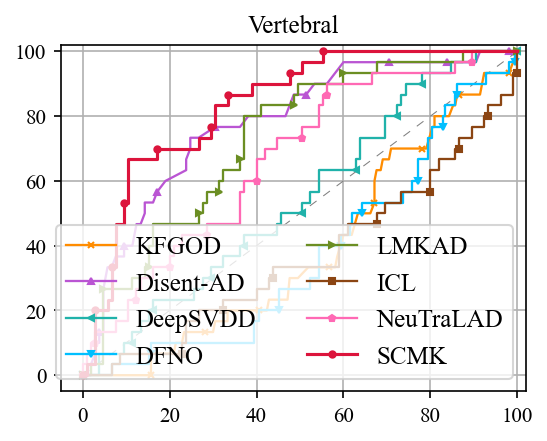

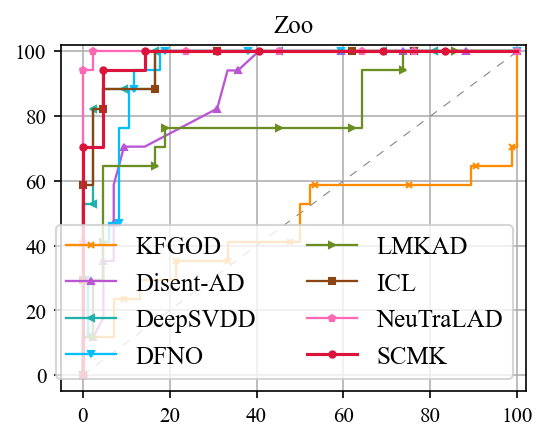

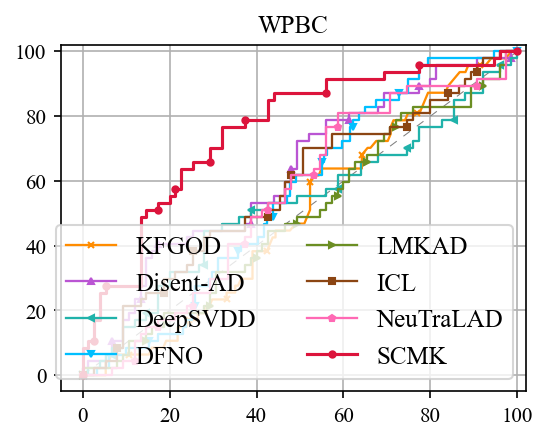

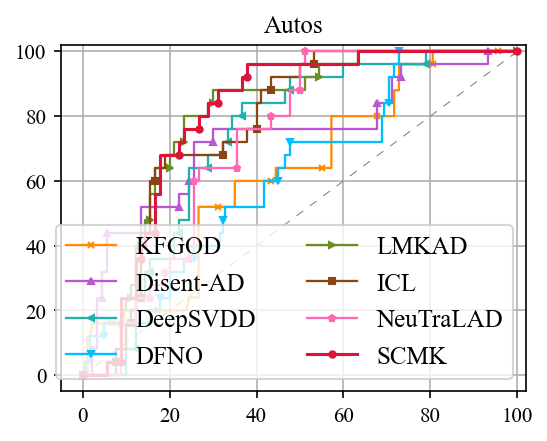

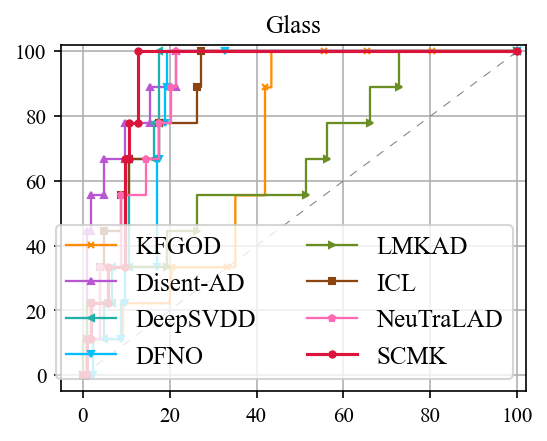

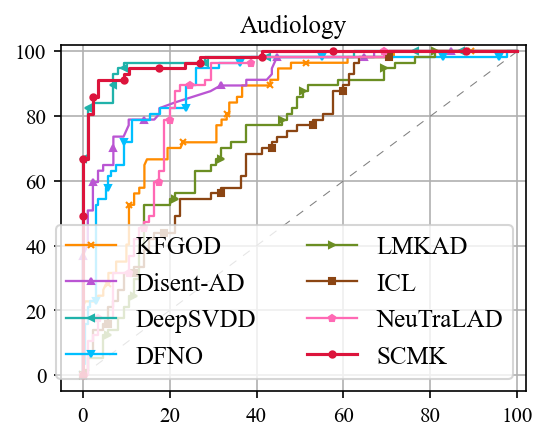

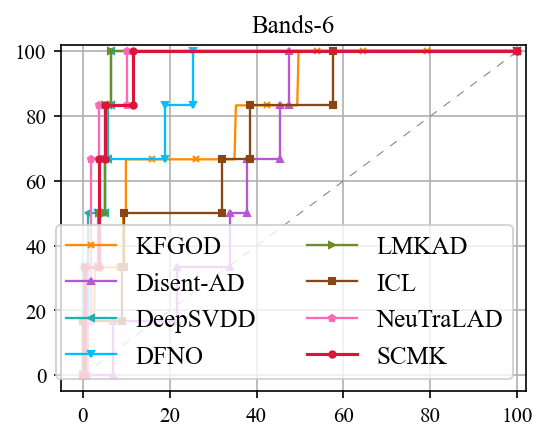

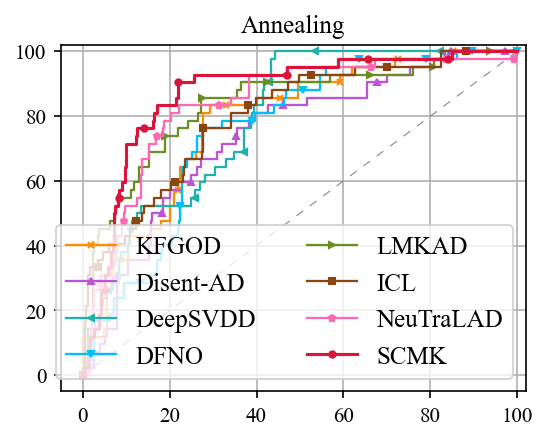

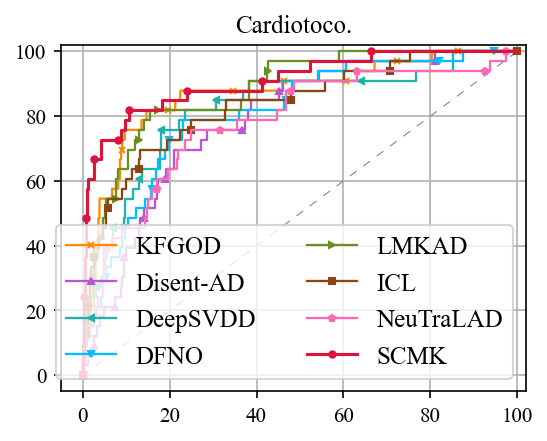

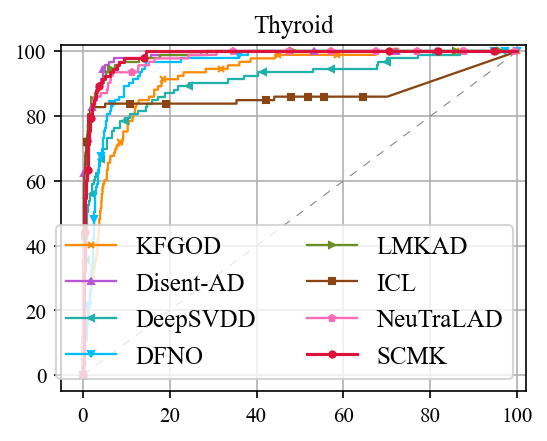

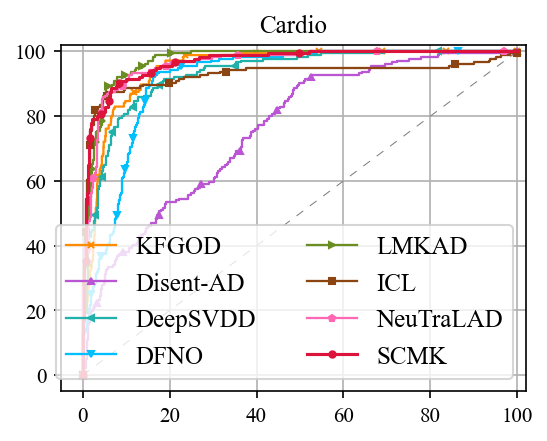

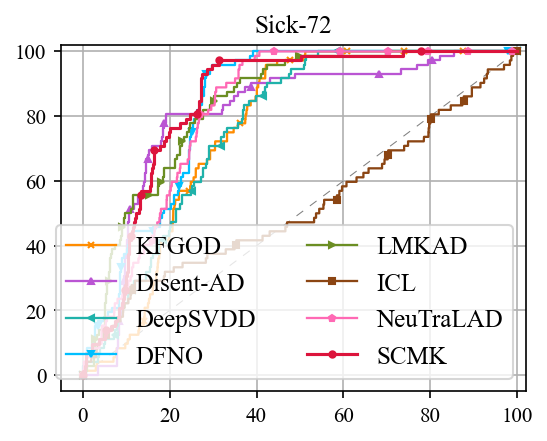

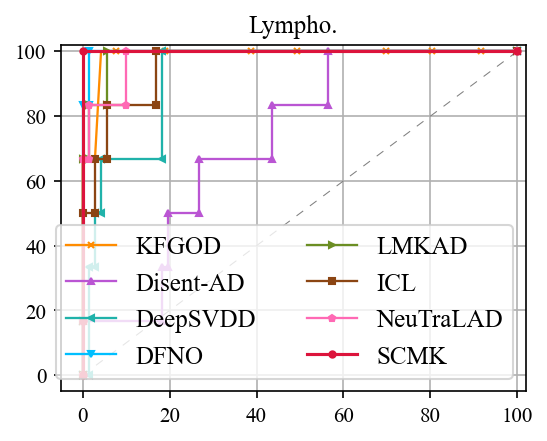

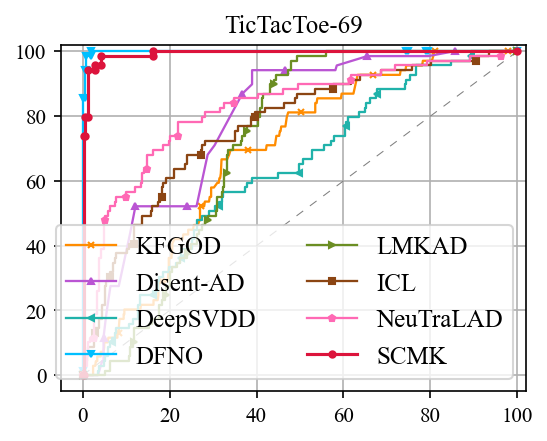

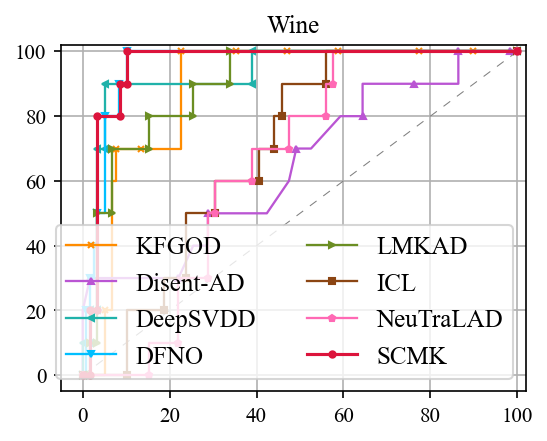

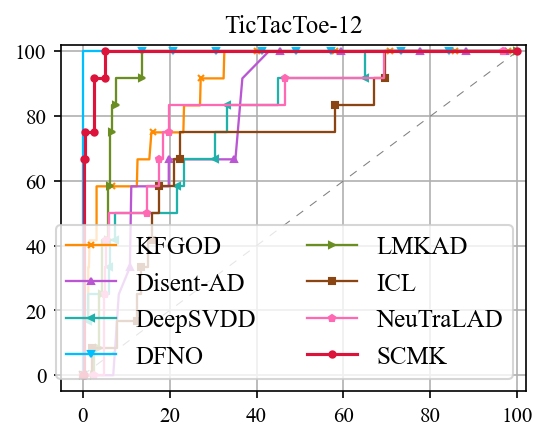

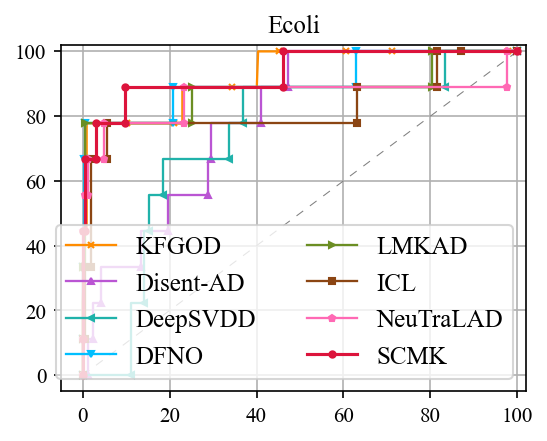

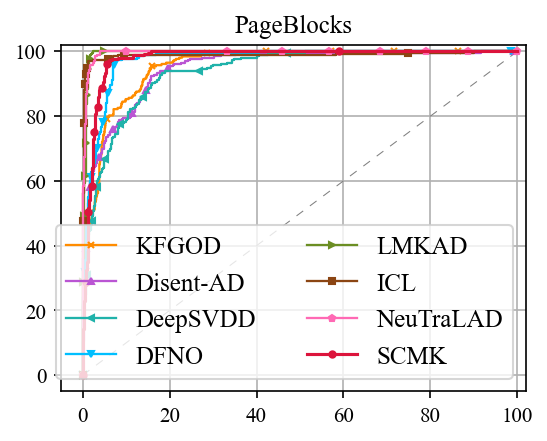

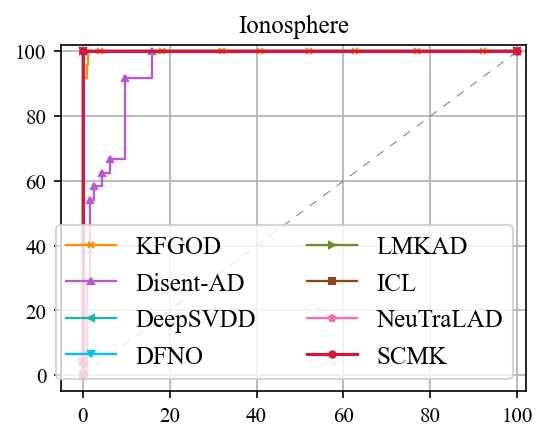

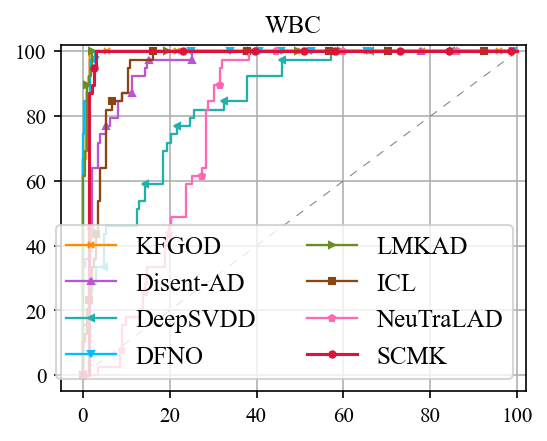

saved per-dataset ROC to: C:/OD/Shihao/5/result/hybrid_score_semi\roc_compare


In [7]:
DISP = {'vertebral':'Vertebral','thyroid':'Thyroid','wbc_malignant_39_variant1':'WBC',
        'glass':'Glass','ecoli':'Ecoli','pageblocks_1_258_variant1':'PageBlocks','wine':'Wine',
        'cardio':'Cardio','cardiotocography_2and3_33_variant1':'Cardiotoco.',
        'tic_tac_toe_negative_69_variant1':'TicTacToe-69','tic_tac_toe_negative_12_variant1':'TicTacToe-12',
        'wpbc_variant1':'WPBC','ionosphere_b_24_variant1':'Ionosphere','zoo_variant1':'Zoo',
        'sick_sick_72_variant1':'Sick-72','autos_variant1':'Autos','annealing_variant1':'Annealing',
        'lymphography':'Lympho.','bands_band_6_variant1':'Bands-6','audiology_variant1':'Audiology'}
out_dir = os.path.join(RESULT_DIR, 'roc_compare'); os.makedirs(out_dir, exist_ok=True)
for stem in DATASETS:
    res = RESULTS.get(stem, {})
    if not res: continue
    fig = plt.figure(figsize=(4, 3), dpi=150)
    plt.plot([0, 1], [0, 1], color='gray', lw=0.5, linestyle=(0, (8, 8)))
    for m in METHODS:
        if m not in res: continue
        fpr, tpr, auc = res[m]; col, mk, lw = STYLE[m]
        plt.plot(fpr, tpr, label=f'{LABEL[m]}', color=col, marker=mk,
                 markevery=max(len(fpr)//8, 1), markersize=3, lw=lw)
    plt.xticks([0,0.2,0.4,0.6,0.8,1], [0,20,40,60,80,100], fontsize=10)
    plt.yticks([0,0.2,0.4,0.6,0.8,1], [0,20,40,60,80,100], fontsize=10)
    plt.xlim(-0.05, 1.02); plt.ylim(-0.05, 1.02); plt.grid(True)
    plt.title(DISP.get(stem, stem[:30]), fontsize=12)
    plt.legend(prop={'size': 12}, ncol=2, loc='lower right')
    fig.patch.set_facecolor('white')
    plt.savefig(os.path.join(out_dir, stem + '_ROC.pdf'), bbox_inches='tight', pad_inches=0.02)
    plt.show(); plt.close()
print('saved per-dataset ROC to:', out_dir)

## G-mean supplement (table similar to Table 2)

**Maximum G-mean** $=\max_t \sqrt{\mathrm{TPR}_t\cdot(1-\mathrm{FPR}_t)}$ over the ROC
operating points -- a threshold-based complement to AUC.
- Split methods (Disent-AD, DeepSVDD, LMKAD, ICL, NeuTraLAD, SCMK): mean$\pm$std over
  seeds 0,1,2 on the held-out test set.
- KFGOD, DFNO: transductive on the full dataset (single value).

Writes `gmean_table.tex` (Table-2 layout) and `result/hybrid_score_semi/gmean_all.csv`.

In [ ]:
# ---- Maximum G-mean per method (mean+/-std over seeds for split methods) ----
from sklearn.metrics import roc_curve
SEEDS = [0, 1, 2]
IC_ROOT = os.path.dirname(ICL_DIR)                       # .../results_split/scores
MAT_DIR = {'Disent_AD': ('Disent_AD_split_seed', '_DisentAD.mat'),
           'DeepSVDD':  ('DeepSVDD_split_seed', '_DeepSVDD.mat'),
           'LMKAD':     ('LMKAD_gauss_split_seed', '_LMKAD.mat')}
CSV_DIR = {'ICL': 'ICL', 'NeuTraLAD': 'NeuTraL'}
SPLIT_METHODS  = ['Disent_AD', 'DeepSVDD', 'LMKAD', 'ICL', 'NeuTraLAD', 'scatter']
SINGLE_METHODS = ['KFGOD', 'DFNO']

def gmean_max(y, s):
    fpr, tpr, _ = roc_curve(y, s)
    return float(np.nanmax(np.sqrt(np.clip(tpr, 0, 1) * np.clip(1 - fpr, 0, 1))))

def seed_scores(method, seed, stem):
    '''(y_test, scores) on the seed-`seed` held-out test set.'''
    if method in MAT_DIR:
        d, suf = MAT_DIR[method]
        r = sio.loadmat(f'{ER}/{d}{seed}/{stem}{suf}')['res_single'][0, 0]
        return (np.asarray(r['labels'], float).ravel().astype(int),
                np.asarray(r['opt_scores'], float).ravel())
    if method in CSV_DIR:
        df = pd.read_csv(f'{IC_ROOT}/seed{seed}/{CSV_DIR[method]}/{stem}_scores.csv')
        return df['label'].values.astype(int), df['anomaly_score'].values.astype(float)
    if method == 'scatter':
        tr, te = split_indices(load_full_y(stem), seed)
        return scatter_test_scores(stem, tr, te)
    raise ValueError(method)

GM = {}   # stem -> {method: (mean, std_or_None)}
for stem in DATASETS:
    y_full = load_full_y(stem); row = {}
    row['KFGOD'] = (gmean_max(y_full, full_data_scores(os.path.join(KFGOD_DIR, stem, f'{stem}_KFGOD.mat'), y_full)), None)
    row['DFNO']  = (gmean_max(y_full, full_data_scores(os.path.join(DFNO_DIR,  stem, f'{stem}_DFNO.mat'),  y_full)), None)
    for m in SPLIT_METHODS:
        gs = [gmean_max(*seed_scores(m, sd, stem)) for sd in SEEDS]
        row[m] = (float(np.mean(gs)), float(np.std(gs, ddof=1)))
    GM[stem] = row
    print(f'{stem:<36} ' + '  '.join(f'{LABEL[m]}={row[m][0]:.3f}' for m in METHODS))
print('mean G-mean:', {LABEL[m]: round(np.mean([GM[s][m][0] for s in DATASETS]), 4) for m in METHODS})

In [ ]:
# ---- Table-2-style LaTeX table of G-mean (bold = best mean per row) ----
COLS = ['KFGOD', 'Disent_AD', 'DeepSVDD', 'DFNO', 'LMKAD', 'ICL', 'NeuTraLAD', 'scatter']
ORDER = ['vertebral','thyroid','wbc_malignant_39_variant1','glass','ecoli',
         'pageblocks_1_258_variant1','wine','cardio','cardiotocography_2and3_33_variant1',
         'tic_tac_toe_negative_12_variant1','tic_tac_toe_negative_69_variant1','wpbc_variant1',
         'ionosphere_b_24_variant1','zoo_variant1','sick_sick_72_variant1','autos_variant1',
         'annealing_variant1','lymphography','bands_band_6_variant1','audiology_variant1']
NAME = {'vertebral':'Vertebral','thyroid':'Thyroid','wbc_malignant_39_variant1':'WBC','glass':'Glass',
        'ecoli':'Ecoli','pageblocks_1_258_variant1':'PageBlocks','wine':'Wine','cardio':'Cardio',
        'cardiotocography_2and3_33_variant1':'Cardiotoco.','tic_tac_toe_negative_12_variant1':'TicTacToe-12',
        'tic_tac_toe_negative_69_variant1':'TicTacToe-69','wpbc_variant1':'WPBC',
        'ionosphere_b_24_variant1':'Ionosphere','zoo_variant1':'Zoo','sick_sick_72_variant1':'Sick-72',
        'autos_variant1':'Autos','annealing_variant1':'Annealing','lymphography':'Lympho.',
        'bands_band_6_variant1':'Bands-6','audiology_variant1':'Audiology'}

def cell(mean, std, bold):
    m = f'{mean:.3f}'; inner = f'\\mathbf{{{m}}}' if bold else m
    return f'${inner}_{{\\pm{std:.3f}}}$' if std is not None else f'${inner}$'

rows = []
for stem in ORDER:
    means = [GM[stem][m][0] for m in COLS]; rmax = max(round(v, 3) for v in means)
    cells = [cell(GM[stem][m][0], GM[stem][m][1], round(GM[stem][m][0], 3) == rmax) for m in COLS]
    rows.append(f'{NAME[stem]:<12} & ' + ' & '.join(cells) + r' \\')
avg  = {m: float(np.mean([GM[s][m][0] for s in ORDER])) for m in COLS}
astd = {m: (float(np.mean([GM[s][m][1] for s in ORDER])) if m in SPLIT_METHODS else None) for m in COLS}
amax = max(round(a, 3) for a in avg.values())
avg_line = r'\textbf{Average} & ' + ' & '.join(cell(avg[m], astd[m], round(avg[m], 3) == amax) for m in COLS) + r' \\'

body = '\n'.join(rows) + '\n\\midrule\n' + avg_line
table = (r'''\begin{table*}[t]
\centering
\caption{Maximum G-mean ($\sqrt{\mathrm{TPR}\cdot\mathrm{TNR}}$) of SCMK against seven recent
detectors on twenty datasets, as a threshold-based complement to the AUC in
Table~\ref{tab:comparison}. The one-class methods (SCMK, Disent-AD, DeepSVDD, LMKAD, ICL,
NeuTraLAD) are reported as mean$_{\pm\text{std}}$ over three random splits (seeds $0,1,2$);
KFGOD and DFNO are transductive on the full set (single-valued). Best mean in each row is in
\textbf{bold}.}
\label{tab:gmean}
\scriptsize
\setlength{\tabcolsep}{4pt}
\resizebox{\textwidth}{!}{
\begin{tabular}{lccccccc c}
\toprule
Dataset & KFGOD & Disent & DeepSVDD & DFNO & LMKAD & ICL & NeuTraLAD & SCMK\\
\midrule
''' + body + r'''
\bottomrule
\end{tabular}
}
\end{table*}
''')

with open(os.path.join(NB_DIR, 'gmean_table.tex'), 'w', encoding='utf-8') as f:
    f.write(table)
# also dump the raw numbers
recs = []
for stem in ORDER:
    d = {'stem': stem, 'name': NAME[stem]}
    for m in COLS:
        d[f'{m}_mean'] = GM[stem][m][0]
        if GM[stem][m][1] is not None: d[f'{m}_std'] = GM[stem][m][1]
    recs.append(d)
pd.DataFrame(recs).to_csv(os.path.join(RESULT_DIR, 'gmean_all.csv'), index=False)
print(table)